# Projeto Trainee CatiJr-2026: Previsão de Preços de Imóveis (House Prices)

## 1. Visão Geral do Problema
O mercado imobiliário é altamente dinâmico e a precificação de uma casa vai muito além do seu tamanho ou número de quartos. Diversos fatores, desde a qualidade do material do telhado até o bairro e a proximidade com ruas principais, influenciam diretamente no valor final de venda. 

O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de **prever o preço final de venda de casas residenciais** localizadas em Ames, Iowa (EUA).

## 2. Contextualização
Este projeto é baseado na famosa competição do Kaggle *"House Prices - Advanced Regression Techniques"*.

Temos à nossa disposição **79 variáveis explicativas** (features) que descrevem quase todos os aspectos de residências na cidade de Ames. O nosso desafio é utilizar técnicas de **Análise Exploratória de Dados (EDA)**, **Engenharia de Atributos (Feature Engineering)** e algoritmos avançados de **Regressão** para encontrar os padrões ocultos nesses dados e estimar o valor da variável alvo (`SalePrice`).

**Principais objetivos desta análise:**
1. Entender quais variáveis têm maior impacto no preço de venda de um imóvel.
2. Tratar dados ausentes e valores atípicos (outliers) de forma inteligente.
3. Construir e otimizar modelos preditivos para obter a menor margem de erro possível.

---

## Importação de bibliotecas e configurações iniciais

In [1]:
# importação de bibliotecas matemáticas e de manipulação de dados
import pandas as pd
import numpy as np

# importação de bibliotecas de vizualização gráfica
import seaborn as sns
import matplotlib.pyplot as plt

# configuração do pandas para vizualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Importação de biblioteca para ignorar avisos visuais desnecessários (warnings)
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas!')

Bibliotecas importadas!


## Bloco 1 - EDA

### Carregamento e visão geral dos dados

In [2]:
# carregando os arquivos csv para o pandas
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
# exbindo informações sobre o df_train
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# usando describe para análises matemáticas da tabela
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# vizualizando as 10 primeiras linhas 
df_train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

### Visualização gráfica da nossa variável alvo (SalePrace)

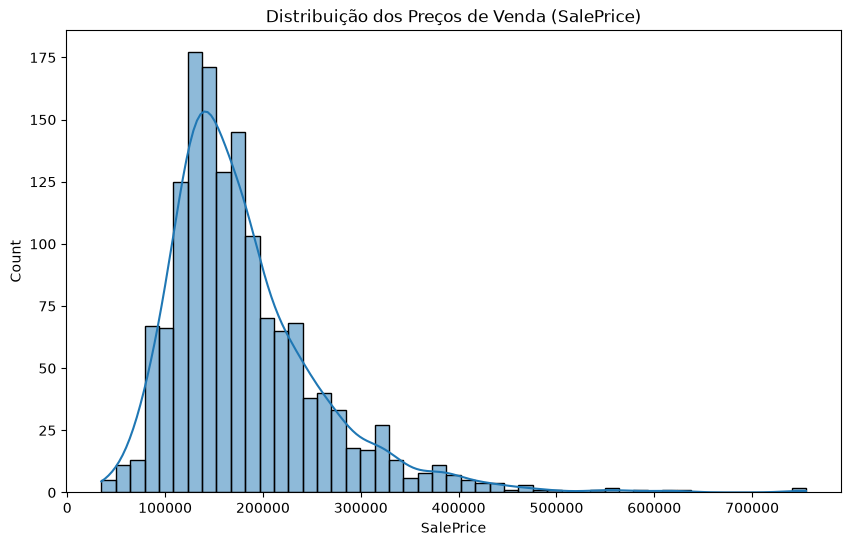

In [6]:
# configura o tamanho do gráfico para não ficar espremido
plt.figure(figsize=(10, 6))

# visualização do histograma (usando a variável df_train)
sns.histplot(data=df_train, x='SalePrice', kde=True)

# adiciona um título
plt.title('Distribuição dos Preços de Venda (SalePrice)')

# exibe o gráfico limpo
plt.show()

### Análise bivariada e correlações

#### Heatmap
Poderemos analisar quais são as variáveis que apresentam maior correlação com o preço de venda.

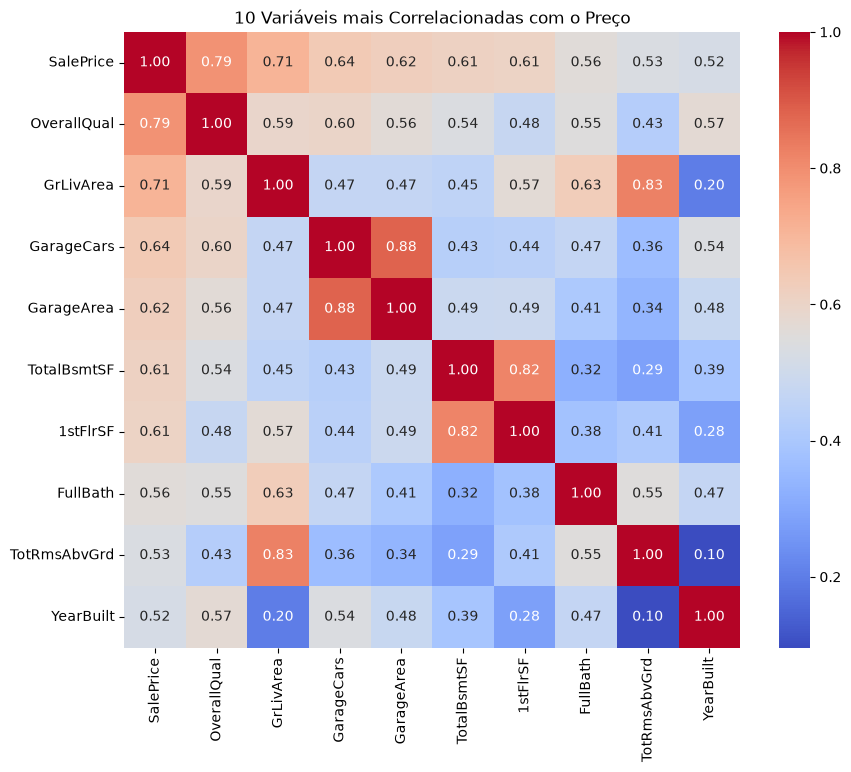

In [7]:
# calcula a matriz de correlação (apenas colunas numéricas)
correlacao = df_train.corr(numeric_only=True)

# pega as 10 variáveis que tem maior correlação com saleprice
colunas_maior_corr = correlacao.nlargest(10, 'SalePrice')['SalePrice'].index

# cria matriz de correlação com as 10 variáveis
matriz_corr = df_train[colunas_maior_corr].corr()

# configura o tamanho do gráfico e desenha o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('10 Variáveis mais Correlacionadas com o Preço')
plt.show()

#### Scatter plot
Com base no Heatmap anterior, identificamos as 6 variáveis que apresentam a maior correlação linear com a nossa variável alvo (`SalePrice`):

* **OverallQual**: Qualidade geral dos materiais e acabamento da casa.
* **GrLivArea**: Área de estar (habitável) acima do solo.
* **GarageCars**: Capacidade da garagem em número de carros.
* **GarageArea**: Área da garagem
* **TotalBsmtSF**: Área total do porão.
* **1stFlrSF**: Área do primeiro andar.

Para entender a dinâmica de cada uma destas variáveis em relação ao preço, vamos gerar uma grade de gráficos de dispersão (*Scatter Plots*). Esta visualização conjunta irá facilitar a identificação de tendências lineares, a dispersão dos dados e a deteção visual de pontos fora da curva (*outliers*).

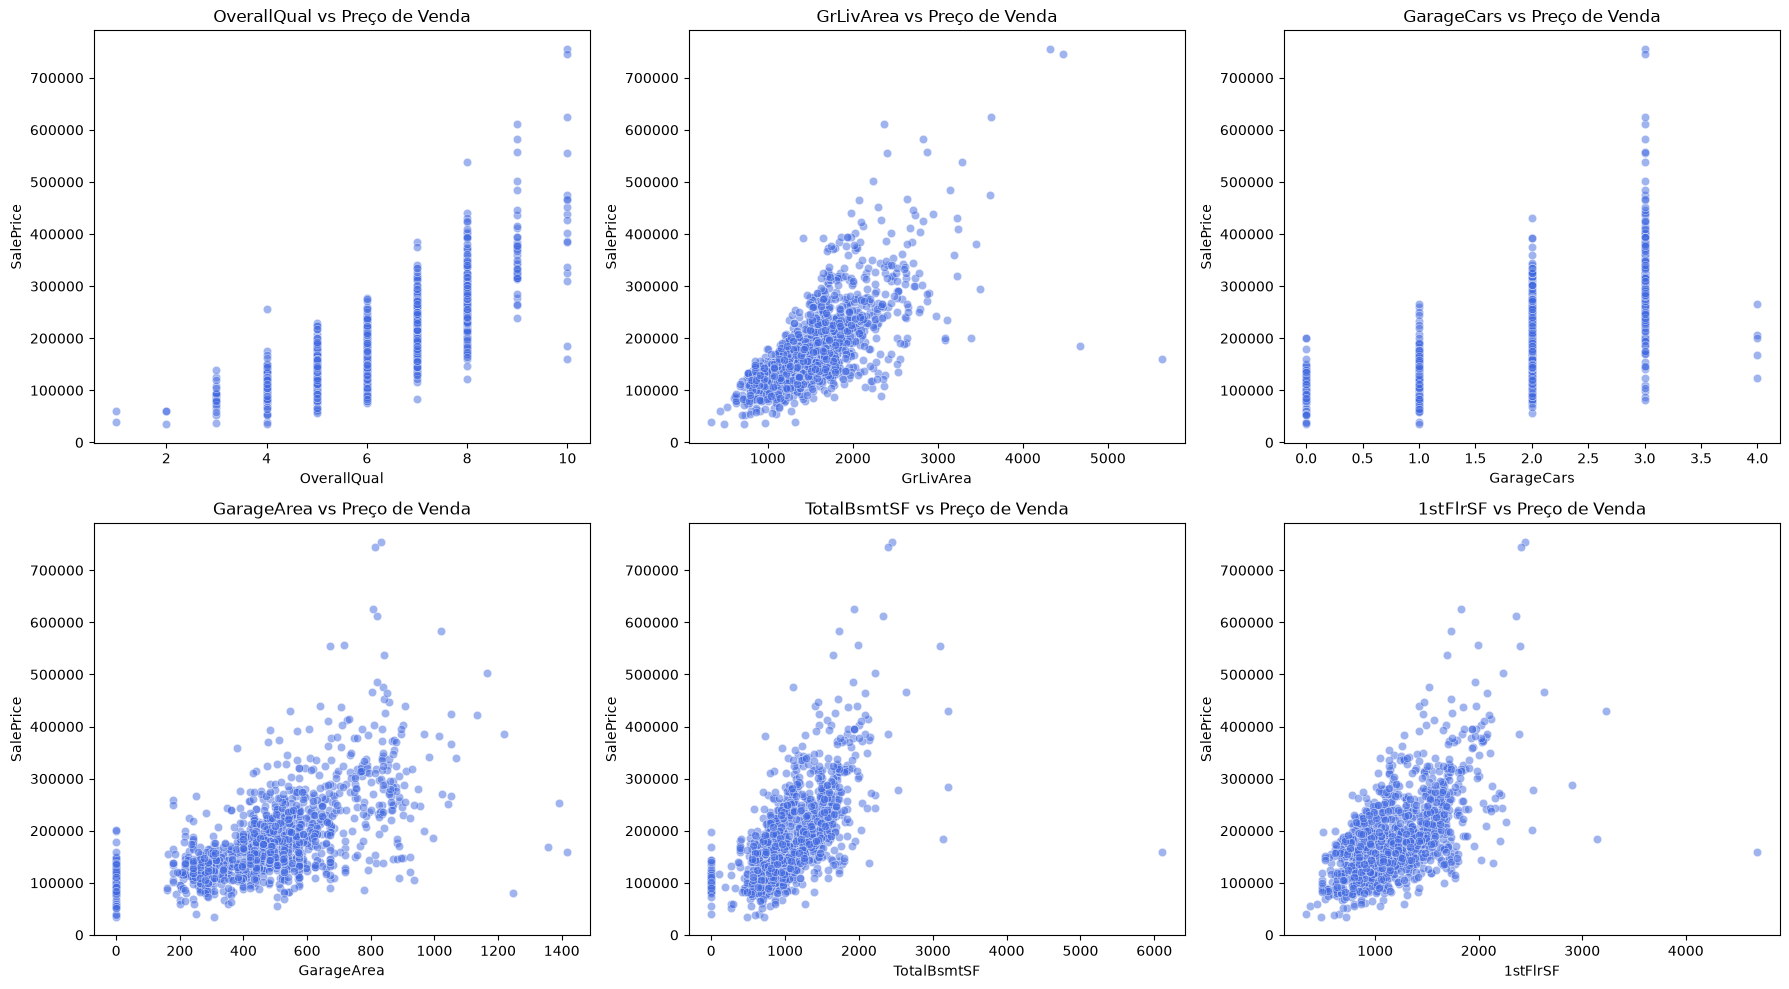

In [8]:
# lista com as variáveis de maior correlação
lista_maior_corr = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea','TotalBsmtSF', '1stFlrSF']

# criando os espaços para os scatter plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# para cada variável na nossa lista, ele desenha o gráfico no espaço correspondente
for i, coluna in enumerate(lista_maior_corr):
    sns.scatterplot(data=df_train, x=coluna, y='SalePrice', ax=axes[i], alpha=0.5, color='royalblue')
    axes[i].set_title(f'{coluna} vs Preço de Venda')

# ajusta os espaços entre os gráficos para não encavalarem e exibe na tela
plt.tight_layout()
plt.show()

## Bloco 2 - Tratamento de valores ausentes
Para realizar um tratamento preciso, vamos dividir as variáveis com dados nulos em dois grupos:
1. **Variáveis Categóricas (Texto):** Onde a ausência de informação (`NaN`) indica que o imóvel não possui aquela característica (ex: sem piscina, sem garagem). Substituiremos por **`"None"`**.
2. **Variáveis Numéricas (Números):** Onde a ausência de informação indica que o valor quantitativo é nulo (ex: se não há garagem, a área da garagem é **`0`**).

In [9]:
# identifica quais colunas têm nulos
nulos_por_coluna = df_train.isnull().sum()
colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0].index

# cria um dicionário para guardar os tipos de cada uma dessas colunas
tipos_das_colunas = df_train[colunas_com_nulos].dtypes

# monta uma tabela organizada mostrando o total de nulos e o tipo de dado
tabela_tipos_nulos = pd.DataFrame({
    'Total de Nulos': df_train[colunas_com_nulos].isnull().sum(),
    'Tipo de Dado': tipos_das_colunas
}).sort_values(by='Total de Nulos', ascending=False)

tabela_tipos_nulos

,Total de Nulos,Tipo de Dado
PoolQC,1453,str
MiscFeature,1406,str
Alley,1369,str
Fence,1179,str
MasVnrType,872,str
FireplaceQu,690,str
LotFrontage,259,float64
GarageType,81,str
GarageYrBlt,81,float64
GarageFinish,81,str


Com base no diagnóstico das variáveis nulas e seus respectivos tipos de dados, aplicaremos as seguintes estratégias de imputação:

1. **Variáveis Categóricas (Texto):** Substituição de `NaN` por **`'None'`**, uma vez que a ausência do dado indica que a casa não possui aquela característica (ex: sem piscina, sem garagem).
2. **Variáveis Numéricas de Garagem e Alvenaria (`GarageYrBlt` e `MasVnrArea`):** Substituição por **`0`**, indicando a inexistência de área ou ano de construção para imóveis sem estas estruturas.
3. **Frente do Terreno (`LotFrontage`):** Sendo uma característica que todo imóvel possui, substituiremos os valores nulos pela **mediana** da coluna, evitando distorções que a média poderia causar devido a terrenos muito grandes.

In [10]:
# selecionando as colunas categóricas com valores nulos
colunas_categoricas = df_train.select_dtypes(include=['object']).columns

# substituindo os valores nulos por 'None'ArithmeticError
for coluna in colunas_categoricas:
    df_train[coluna] = df_train[coluna].fillna('None')

# substituindo os valores por 0
df_train['GarageYrBlt'] = df_train['GarageYrBlt'].fillna(0)
df_train['MasVnrArea'] = df_train['MasVnrArea'].fillna(0)

# calculando a mediana e substituindo pelos valores nulos
mediana_frontage = df_train['LotFrontage'].median()
df_train['LotFrontage'] = df_train['LotFrontage'].fillna(mediana_frontage)

# verificação
nulos_restantes = df_train.isnull().sum().sum()
print(f"Valores nulos restantes: {nulos_restantes}")

Valores nulos restantes: 0


## Bloco 3 - Tratamento de outliers
Ao analisarmos os gráficos bivariados, identificamos duas anomalias visuais marcantes em relação à variável alvo (`SalePrice`):
1. **GrLivArea (Área):** Duas casas gigantes (área > 4.000) vendidas por menos de $300.000.
2. **OverallQual (Qualidade):** Duas casas com nota máxima (nota = 10) vendidas por menos de $200.000.

Para evitar a remoção arbitrária de dados, formulamos uma hipótese: **Será que essas anomalias representam exatamente os mesmos imóveis?** Vamos realizar um cruzamento de dados para identificar os índices dessas observações em ambas as variáveis e comprovar nossa hipótese antes de prosseguir com a exclusão.

In [11]:
# filtrando as linhas que violam o padrão de área(GrLivArea)
outliers_area = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)]

# filtrando as linhas que violam o padrão de qualidade(OveralQual)
outliers_qualidade = df_train[(df_train['OverallQual'] == 10) & (df_train['SalePrice'] < 200000)]

# analisando os ID's dos outliers
print(f"Índices das casas que apresentam anomalia na área(GrLivArea): {list(outliers_area.index)}")
print(f"Índices das casas que apresentam anomalia na qualidade(OverallQual): {list(outliers_qualidade.index)}")

Índices das casas que apresentam anomalia na área(GrLivArea): [523, 1298]
Índices das casas que apresentam anomalia na qualidade(OverallQual): [523, 1298]


In [12]:
# exibindo os detalhes dessas casas para confirmar a duplicidade
print("\nDETALHES DOS IMÓVEIS IDENTIFICADOS:")
outliers_area[['GrLivArea', 'OverallQual', 'SalePrice']]
outliers_qualidade[['GrLivArea', 'OverallQual', 'SalePrice']]


DETALHES DOS IMÓVEIS IDENTIFICADOS:


,GrLivArea,OverallQual,SalePrice
523,4676,10,184750
1298,5642,10,160000


Como pôde ser observado, nossa hipótese estava correta, as anomalias representam os mesmos imóveis. Logo iremos realizar o tratamento dos outliers.

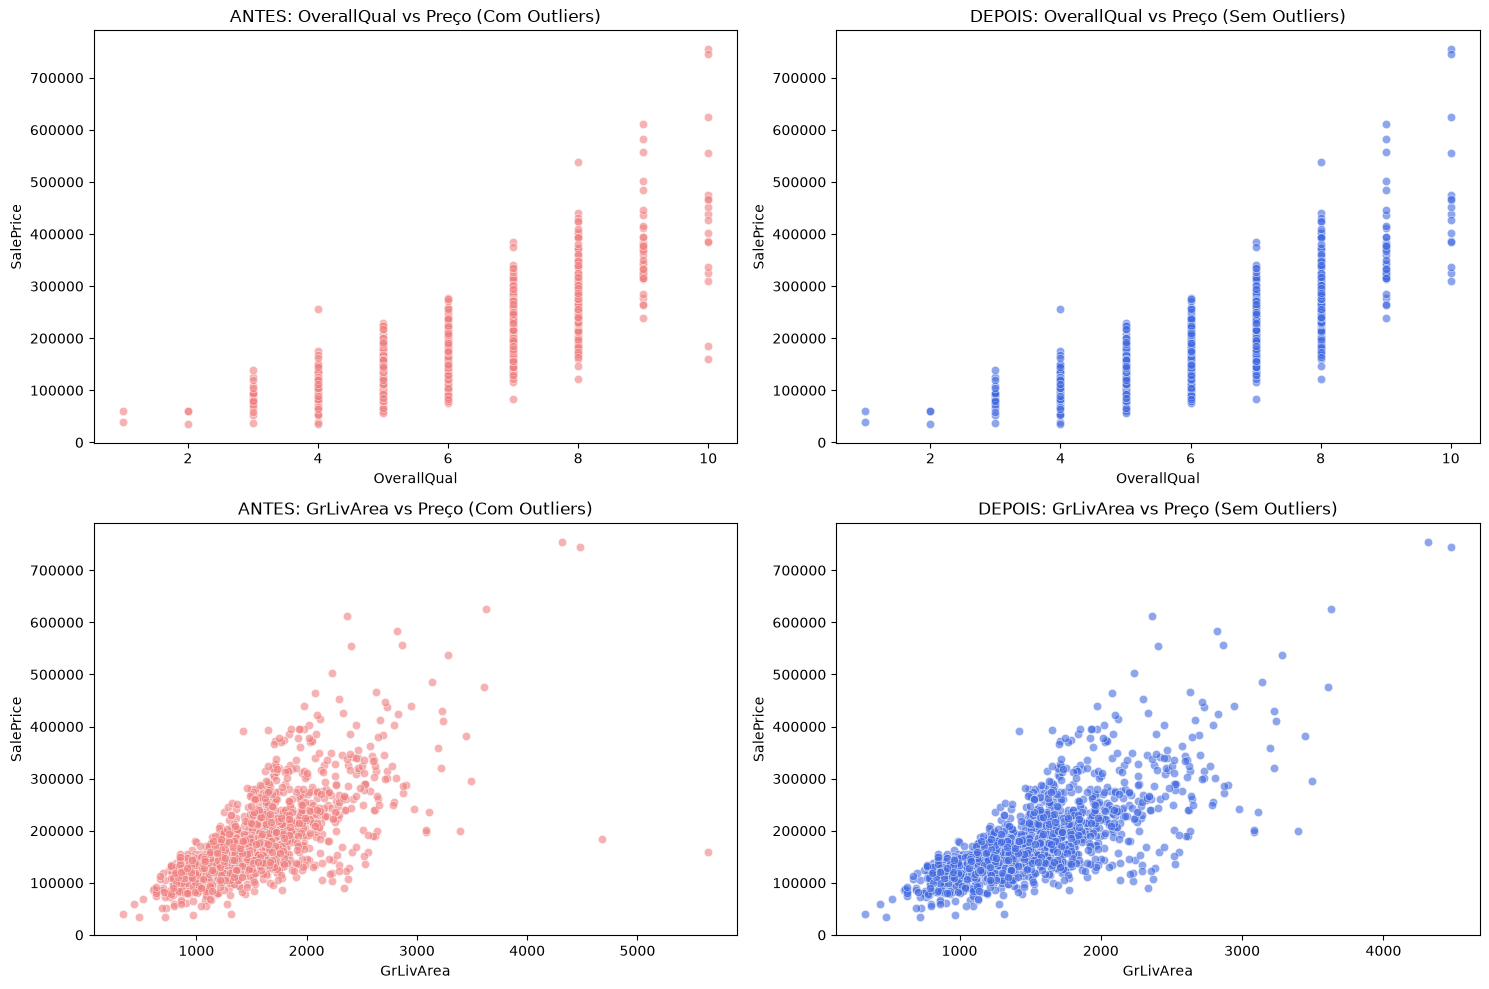

Sucesso! Os outliers [523, 1298] foram excluídos definitivamente do dataset.


In [13]:
# criando a tela para mostrarmoso antes e depois
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# coluna 1 (antes da remoção)
# OverallQual vs Preço
sns.scatterplot(data=df_train, x='OverallQual', y='SalePrice', ax=axes[0, 0], color='lightcoral', alpha=0.6)
axes[0, 0].set_title('ANTES: OverallQual vs Preço (Com Outliers)')

# GrLivArea vs Preço
sns.scatterplot(data=df_train, x='GrLivArea', y='SalePrice', ax=axes[1, 0], color='lightcoral', alpha=0.6)
axes[1, 0].set_title('ANTES: GrLivArea vs Preço (Com Outliers)')


# --- EXCLUSÃO DOS OUTLIERS ---
indices_outliers = outliers_area.index
df_train = df_train.drop(indices_outliers)


# coluna 2 (depois da remoção)
# OverallQual vs Preço (Limpo)
sns.scatterplot(data=df_train, x='OverallQual', y='SalePrice', ax=axes[0, 1], color='royalblue', alpha=0.6)
axes[0, 1].set_title('DEPOIS: OverallQual vs Preço (Sem Outliers)')

# GrLivArea vs Preço (Limpo)
sns.scatterplot(data=df_train, x='GrLivArea', y='SalePrice', ax=axes[1, 1], color='royalblue', alpha=0.6)
axes[1, 1].set_title('DEPOIS: GrLivArea vs Preço (Sem Outliers)')

plt.tight_layout()
plt.show()

print(f"Sucesso! Os outliers {list(indices_outliers)} foram excluídos definitivamente do dataset.")